# セットアップ

Cloning into 'DeepSeekCode'...
remote: Enumerating objects: 326, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 326 (delta 23), reused 8 (delta 3), pack-reused 288 (from 1)
Receiving objects: 100% (326/326), 4.04 MiB | 17.54 MiB/s, done.
Resolving deltas: 100% (186/186), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 60.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# 1. DeepSeekMoE（混合専門家）

**「足し算のときは、どの Routed Expert が選ばれるのか？」**
を実際に数えてグラフ化。

（次の `MoE` クラスには「いま選んだ専門家の番号」(`last_topk_indices`) を記録）


In [ ]:
model.main_model.layers[0].feed_forward

FeedForward(
  (fc1): Linear(in_features=64, out_features=256, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
)

In [ ]:
model.main_model.layers[2].feed_forward

MoE(
  (shared_experts): ModuleList(
    (0): Expert(
      (w1): Linear(in_features=64, out_features=128, bias=False)
      (w2): Linear(in_features=128, out_features=64, bias=False)
      (w3): Linear(in_features=64, out_features=128, bias=False)
    )
  )
  (routed_experts): ModuleList(
    (0-3): 4 x Expert(
      (w1): Linear(in_features=64, out_features=128, bias=False)
      (w2): Linear(in_features=128, out_features=64, bias=False)
      (w3): Linear(in_features=64, out_features=128, bias=False)
    )
  )
)

## 2-1. かんたんなパターンを覚えさせる

「1, 2, 3 の次に 6 か 9 が来る」規則を学習させて、ちゃんと覚えるか確認します。
**学習データ `tokens` は下のセルで手作業で作り、`test.pattern_demo` に渡します。**
数字を書き換えれば、好きなパターンを学習させて試せます。

In [ ]:
# 負荷分散モード（True=auxiliary loss free / False=従来の補助損失）
aux_loss_free = False  #@param {type:"boolean"}

In [ ]:
# 学習（モジュール化された関数を呼ぶだけ。model がその場で更新される）
test.train_pattern(model, args, tokens, num_epochs=100, aux_loss_free=aux_loss_free)

/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


学習開始（100 エポック, データ 2 問, モード: auxiliary loss あり（従来方式））
  epoch   50  loss 0.0850
  epoch  100  loss 0.0234
学習終了


DeepSeekCode(
  (embedding): Embedding(100, 64)
  (output_head): Linear(in_features=64, out_features=100, bias=True)
  (main_model): MainModel(
    (embedding): Embedding(100, 64)
    (layers): ModuleList(
      (0): TransformerBlock(
        (attention): MLA(
          (q_down_proj): Linear(in_features=64, out_features=32, bias=True)
          (q_norm): RMSNorm()
          (qc_up_proj): Linear(in_features=32, out_features=192, bias=True)
          (qr_up_proj): Linear(in_features=32, out_features=64, bias=True)
          (kr_proj): Linear(in_features=64, out_features=16, bias=True)
          (kr_norm): RMSNorm()
          (kv_down_proj): Linear(in_features=64, out_features=16, bias=True)
          (kv_norm): RMSNorm()
          (kc_up_proj): Linear(in_features=16, out_features=192, bias=True)
          (vc_up_proj): Linear(in_features=16, out_features=192, bias=True)
          (attention): ScaledDotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
    

### 学習済み model で「次のトークン」を確認する

`test.predict_next(model, args, ids)` は、系列 `ids` を学習済み model に見せて
**最後の位置のロジット**（語彙数ぶんのスコア）を返します。
`int(...argmax())` で「次に来ると予測したトークン」が取り出せます。

中身を見たいときは `import inspect; print(inspect.getsource(test.predict_next))` で確認できます。

# 3. 四則演算でエキスパートの専門化を観察する

データ生成・パラメータ・モデル生成はノート側。学習と可視化は `test` の関数で行います。

## 3-1. 学習しながら専門家の使われ方を動画で見る

`FRAME_INTERVAL_MS` 相当の `frame_interval_ms` を大きくするとゆっくり再生になります。

In [ ]:
# 負荷分散モード（True=auxiliary loss free / False=従来の補助損失）
aux_loss_free = False  #@param {type:"boolean"}

In [ ]:
# 四則演算を学習しながら、専門家の使われ方の変化を動画にして表示
test.train_arith_with_animation(model, args, ds, num_epochs=300,
                              frame_interval_ms=600, aux_loss_free=aux_loss_free)

学習開始（300 エポック, データ 287 問, モード: auxiliary loss あり（従来方式））
  epoch   50  loss 0.5938
  epoch  100  loss 0.5159
  epoch  150  loss 0.4921
  epoch  200  loss 0.4965
  epoch  250  loss 0.4838
  epoch  300  loss 0.4810
学習終了
GIF を保存: arith_frames/arith.gif


{'frame_dir': 'arith_frames', 'target_layer': 2, 'aux_loss_free': False}

## 3-2. 学習後の結果（棒グラフ・足し算担当の特定）

# 4. 日本語をまぜて、専門家の「役割分担」を見る

数字・記号・日本語という性質の違うトークンをまぜると、専門家が **役割ごと** に分業し始めます。

## 4-1. 学習しながら「分業の現れ方」を動画で見る

最初はのっぺりしていたヒートマップが、学習が進むとカテゴリごとにブロックに分かれていきます。

In [ ]:
# 負荷分散モード（True=auxiliary loss free / False=従来の補助損失）
aux_loss_free = True  #@param {type:"boolean"}

In [ ]:
# 日本語まぜこぜを学習しながら、種類ごとの分業の現れ方を動画にして表示
test.train_jp_with_animation(model, args, ds, num_epochs=200,
                           frame_interval_ms=600, aux_loss_free=aux_loss_free)

学習開始（200 エポック, データ 861 問, モード: aux-loss-free（expert bias で負荷分散））


/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


  epoch   50  loss 0.5051
  epoch  100  loss 0.4780
  epoch  150  loss 0.4820
  epoch  200  loss 0.4765
学習終了
GIF を保存: jp_frames/jp.gif


{'frame_dir': 'jp_frames', 'target_layer': 2, 'aux_loss_free': True}

## 4-2. 学習後のヒートマップ（種類 × 専門家）

分離スコア: 0.569 （1に近いほど分業がはっきり）


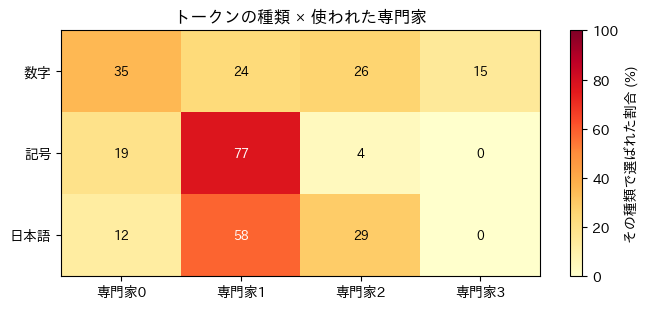

各カテゴリの主担当専門家:
  数字   → 専門家0
  記号   → 専門家1
  日本語  → 専門家1


In [ ]:
usage, target_layer = test.collect_usage_by_category(model, args, ds)
print('分離スコア:', round(test.separation_score(usage, ds), 3), '（1に近いほど分業がはっきり）')
test.plot_category_heatmap(usage, args.n_routed_experts, ds)
test.jp_category_report(usage, target_layer, ds)

## 4-3. 文を「専門家の色」で塗り分けて見る

各トークンが、担当した専門家の色で表示されます。数字・日本語・記号で色（＝専門家）が分かれていれば成功です。

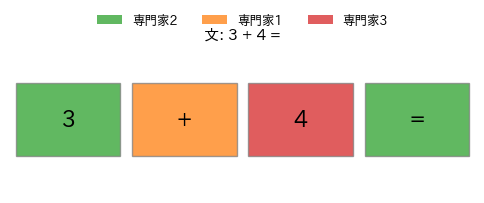

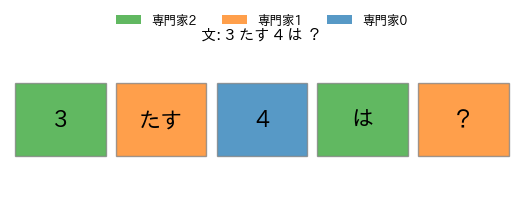

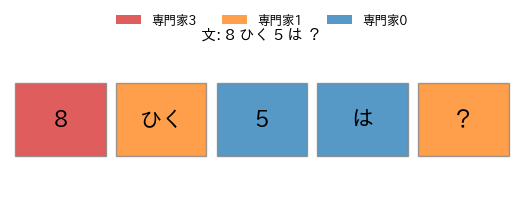

In [ ]:
TOK2ID = ds.TOK2ID
examples = [
    [TOK2ID['3'], TOK2ID['+'],     TOK2ID['4'], TOK2ID['=']],
    [TOK2ID['3'], TOK2ID['たす'],   TOK2ID['4'], TOK2ID['は'], TOK2ID['？']],
    [TOK2ID['8'], TOK2ID['ひく'],   TOK2ID['5'], TOK2ID['は'], TOK2ID['？']],
]
for ex in examples:
    test.show_token_experts(model, args, ex, ds)

# 5. なかまわけクイズで「意味」による分業を見る

「いぬ と ねこ は ？」→「どうぶつ」のように、単語の**なかま（カテゴリ）**を当てるクイズを学習させます。

第4章との違いがポイントです。

- 第4章は「数字・記号・日本語」という**見た目（トークンの種類）**で分業しました。
- このクイズの単語（どうぶつ・たべもの・のりもの）は**すべてひらがなの名詞**で、文の中の**位置もまったく同じ**です。
- つまり専門家が分かれるとしたら、手がかりは**単語の意味（どのなかまか）**しかありません。

ルーティングが「意味」まで学習することを確かめましょう。
※ 前の章の `model` / `args` / `ds` を上書きしないよう、変数名は `model_quiz` / `args_quiz` / `ds_quiz` にしています。

In [ ]:
# @title データ生成 → パラメータ → モデル生成（なかまわけクイズ）
torch.manual_seed(42)
from types import SimpleNamespace

def build_quiz_dataset(context_size=8, mtp_depth=1):
    """なかまわけクイズのデータセットを作って返す。

    文の形式は2つ（答えの直前までが問題）:
      「いぬ は ？ どうぶつ」
      「いぬ と ねこ は ？ どうぶつ」（同じなかまの2語）
    3つのなかまの単語はぜんぶひらがな名詞で、文中の位置も同じ
    → 分業の手がかりは「意味」だけ。
    """
    ANIMALS  = ['いぬ', 'ねこ', 'うま', 'とり', 'さかな', 'うさぎ', 'ぞう', 'さる']
    FOODS    = ['りんご', 'ぱん', 'すし', 'みかん', 'ごはん', 'けーき', 'たまご', 'にく']
    VEHICLES = ['ばす', 'くるま', 'でんしゃ', 'ひこうき', 'ふね', 'じてんしゃ', 'たくしー', 'ばいく']
    ID2TOK = ANIMALS + FOODS + VEHICLES + ['は', 'と', '？', 'どうぶつ', 'たべもの', 'のりもの', 'PAD']
    TOK2ID = {t: i for i, t in enumerate(ID2TOK)}
    PAD = TOK2ID['PAD']
    CATEGORIES = ['どうぶつ', 'たべもの', 'のりもの']
    GROUPS = {'どうぶつ': ANIMALS, 'たべもの': FOODS, 'のりもの': VEHICLES}

    def token_category(t):
        if 0 <= t <= 7:   return 'どうぶつ'
        if 8 <= t <= 15:  return 'たべもの'
        if 16 <= t <= 23: return 'のりもの'
        return None  # 「は」「と」「？」答えトークンなどはカテゴリなし

    seq_total = context_size + mtp_depth + 1
    def pad(s):
        return s + [PAD] * (seq_total - len(s))

    seqs = []
    for cat, words in GROUPS.items():
        ans = TOK2ID[cat]
        for w in words:                        # 「いぬ は ？ どうぶつ」
            seqs.append(pad([TOK2ID[w], TOK2ID['は'], TOK2ID['？'], ans]))
        for w1 in words:                       # 「いぬ と ねこ は ？ どうぶつ」
            for w2 in words:
                if w1 == w2:
                    continue
                seqs.append(pad([TOK2ID[w1], TOK2ID['と'], TOK2ID[w2],
                                 TOK2ID['は'], TOK2ID['？'], ans]))

    data = torch.tensor(seqs, dtype=torch.long)
    return SimpleNamespace(data=data, ID2TOK=ID2TOK, TOK2ID=TOK2ID,
                           CATEGORIES=CATEGORIES, GROUPS=GROUPS,
                           token_category=token_category,
                           vocab_size=len(ID2TOK), context_size=context_size,
                           mtp_depth=mtp_depth, seq_total=seq_total, PAD=PAD, pad=pad)

ds_quiz = build_quiz_dataset(context_size=8)

args_quiz = Args(
    d_model=64,
    vocab_size=ds_quiz.vocab_size,
    n_layers=3,
    n_heads=4,
    d_c=16, d_cQ=32, d_rope=16, d_head=48,
    context_size=ds_quiz.context_size,
    norm_eps=1e-8,
    max_seq_len=100,
    rope_theta=10000,
    n_shared_experts=1,
    n_routed_experts=4,
    n_activated_experts=1,
    moe_bias_update_speed=0.01,
    aux_loss_alpha=0.001,
    moe_inter_dim=64,
    multi_token_depth=ds_quiz.mtp_depth,
    lambda_mtp=0.1
)
model_quiz = DeepSeekCode(args_quiz)
print('データ数:', ds_quiz.data.size(0), ' 語彙数:', ds_quiz.vocab_size)

データ数: 192  語彙数: 31


## 5-1. 学習しながら「なかま分け」の現れ方を動画で見る

ヒートマップ系の関数は `ds` を差し替えるだけで再利用できます。
最初は3つのなかまが同じ専門家にまざっていますが、クイズに正解できるようになるにつれて、
**どうぶつ担当・たべもの担当・のりもの担当**に分かれていきます。

In [ ]:
# 負荷分散モード（True=auxiliary loss free / False=従来の補助損失）
aux_loss_free = True  #@param {type:"boolean"}

In [ ]:
# なかまわけクイズを学習しながら、なかまごとの分業の現れ方を動画にして表示
test.train_jp_with_animation(model_quiz, args_quiz, ds_quiz, num_epochs=300,
                           frame_interval_ms=600, aux_loss_free=aux_loss_free,
                           frame_dir='quiz_frames')

学習開始（300 エポック, データ 192 問, モード: aux-loss-free（expert bias で負荷分散））


/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


  epoch   50  loss 0.2783
  epoch  100  loss 0.2720
  epoch  150  loss 0.2684
  epoch  200  loss 0.2658
  epoch  250  loss 0.2705
  epoch  300  loss 0.2656
学習終了
GIF を保存: quiz_frames/jp.gif


{'frame_dir': 'quiz_frames', 'target_layer': 2, 'aux_loss_free': True}

## 5-2. 学習後のヒートマップ（なかま × 専門家）

第4章と同じヒートマップですが、今度の行は「見た目の種類」ではなく**意味のなかま**です。
なかまごとに違う専門家の列が濃くなっていれば、ルーティングが意味を学習した証拠です。

分離スコア: 0.889 （1に近いほど分業がはっきり）


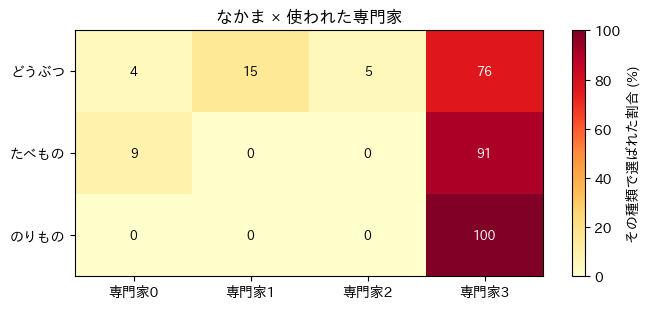

各カテゴリの主担当専門家:
  どうぶつ → 専門家3
  たべもの → 専門家3
  のりもの → 専門家3


In [ ]:
usage, target_layer = test.collect_usage_by_category(model_quiz, args_quiz, ds_quiz)
print('分離スコア:', round(test.separation_score(usage, ds_quiz), 3), '（1に近いほど分業がはっきり）')
test.plot_category_heatmap(usage, args_quiz.n_routed_experts, ds_quiz,
                           title='なかま × 使われた専門家')
test.jp_category_report(usage, target_layer, ds_quiz)

## 5-3. クイズに正解できるか＋文を「専門家の色」で塗り分ける

まず24単語ぜんぶでクイズの正解率を確認し、
つぎに各トークンを担当した専門家の色で塗り分けます。
最後の「ぞう と けーき」は学習データにない**なかま違いのまぜこぜ文**です。
それでも各トークンは自分のなかまの専門家に振り分けられるでしょうか？

In [ ]:
# クイズに正解できるか（24 単語ぜんぶ確認）
T = ds_quiz.TOK2ID
n_ok = 0
for cat, words in ds_quiz.GROUPS.items():
    for w in words:
        logits = test.predict_next(model_quiz, args_quiz, [T[w], T['は'], T['？']])
        pred = ds_quiz.ID2TOK[int(logits.argmax())]
        mark = '○' if pred == cat else '×'
        n_ok += (pred == cat)
        print(f'{mark}「{w} は ？」→ {pred}（正解: {cat}）')
print(f'\n正解: {n_ok} / 24')

○「いぬ は ？」→ どうぶつ（正解: どうぶつ）
○「ねこ は ？」→ どうぶつ（正解: どうぶつ）
○「うま は ？」→ どうぶつ（正解: どうぶつ）
○「とり は ？」→ どうぶつ（正解: どうぶつ）
○「さかな は ？」→ どうぶつ（正解: どうぶつ）
○「うさぎ は ？」→ どうぶつ（正解: どうぶつ）
○「ぞう は ？」→ どうぶつ（正解: どうぶつ）
○「さる は ？」→ どうぶつ（正解: どうぶつ）
○「りんご は ？」→ たべもの（正解: たべもの）
○「ぱん は ？」→ たべもの（正解: たべもの）
○「すし は ？」→ たべもの（正解: たべもの）
○「みかん は ？」→ たべもの（正解: たべもの）
○「ごはん は ？」→ たべもの（正解: たべもの）
○「けーき は ？」→ たべもの（正解: たべもの）
○「たまご は ？」→ たべもの（正解: たべもの）
○「にく は ？」→ たべもの（正解: たべもの）
○「ばす は ？」→ のりもの（正解: のりもの）
○「くるま は ？」→ のりもの（正解: のりもの）
○「でんしゃ は ？」→ のりもの（正解: のりもの）
○「ひこうき は ？」→ のりもの（正解: のりもの）
○「ふね は ？」→ のりもの（正解: のりもの）
○「じてんしゃ は ？」→ のりもの（正解: のりもの）
○「たくしー は ？」→ のりもの（正解: のりもの）
○「ばいく は ？」→ のりもの（正解: のりもの）

正解: 24 / 24


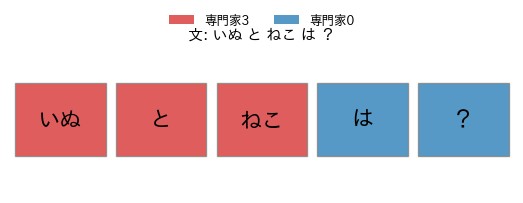

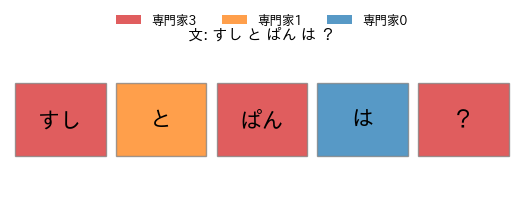

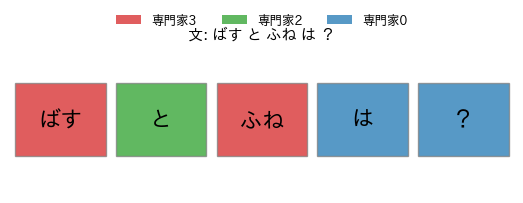

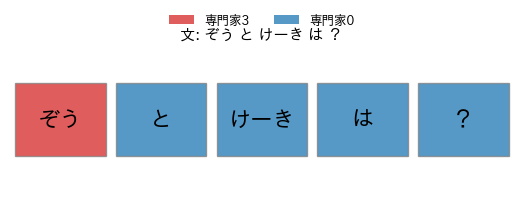

In [ ]:
# 文を「専門家の色」で塗り分けて見る
T = ds_quiz.TOK2ID
examples = [
    [T['いぬ'], T['と'], T['ねこ'], T['は'], T['？']],
    [T['すし'], T['と'], T['ぱん'], T['は'], T['？']],
    [T['ばす'], T['と'], T['ふね'], T['は'], T['？']],
    [T['ぞう'], T['と'], T['けーき'], T['は'], T['？']],  # なかま違いのまぜこぜ（学習データにない文）
]
for ex in examples:
    test.show_token_experts(model_quiz, args_quiz, ex, ds_quiz)

# 6. 自由に実験する（Colab で直接書く）

`test` の関数はすべて `model` / `args` / `ds` を引数で受け取るので、
ここに好きなコードを書いて組み合わせられます。下は例です。

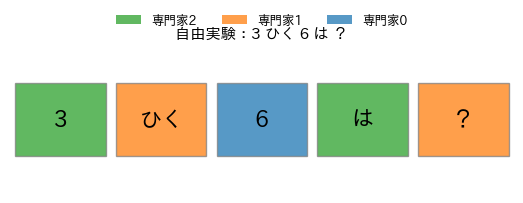

In [ ]:
# 好きな文の担当専門家を見る
my_sentence = [ds.TOK2ID['3'], ds.TOK2ID['ひく'], ds.TOK2ID['6'], ds.TOK2ID['は'], ds.TOK2ID['？']]
test.show_token_experts(model, args, my_sentence, ds, title='自由実験：3 ひく 6 は ？')

In [ ]:
TOK2ID.keys()

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '*', '/', '=', 'たす', 'ひく', 'かける', 'わる', 'は', '？', 'PAD'])

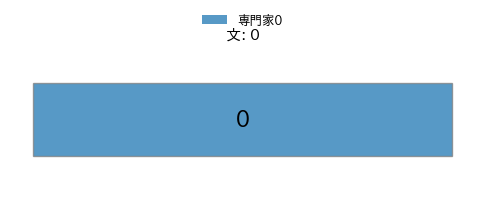

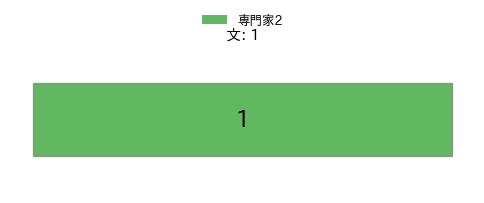

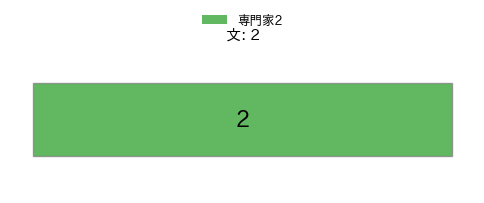

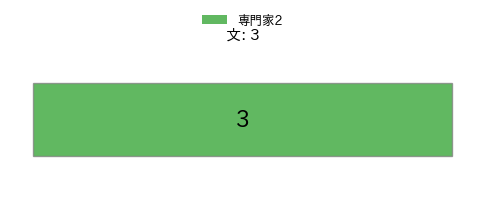

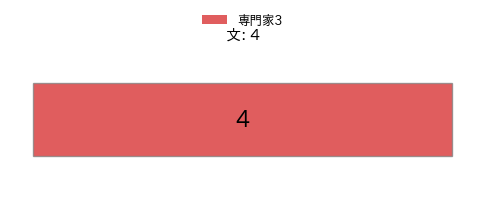

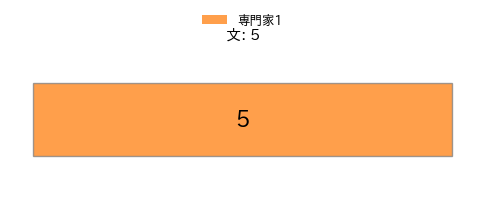

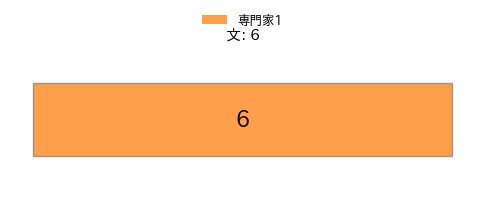

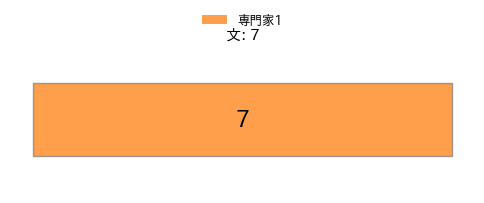

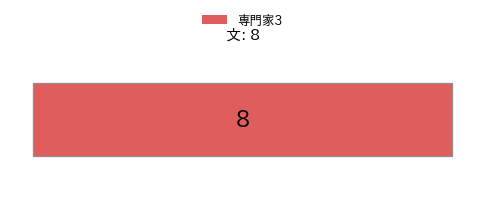

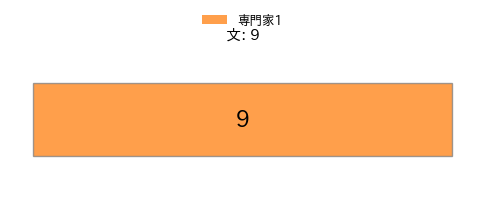

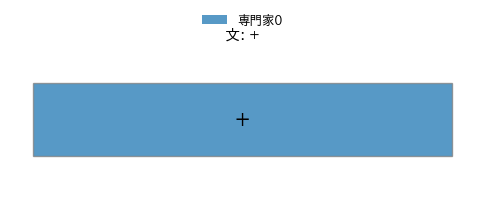

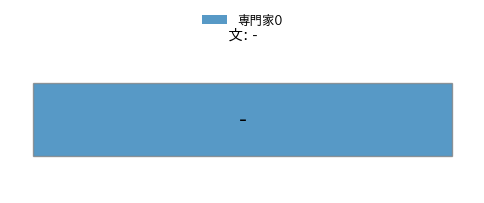

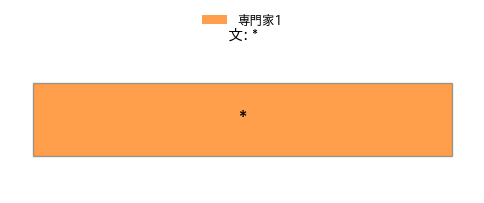

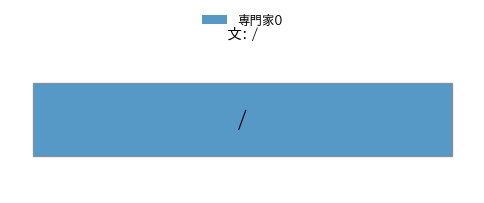

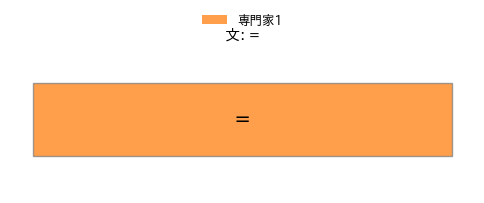

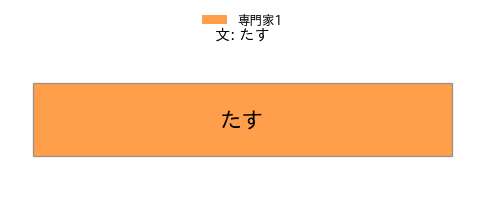

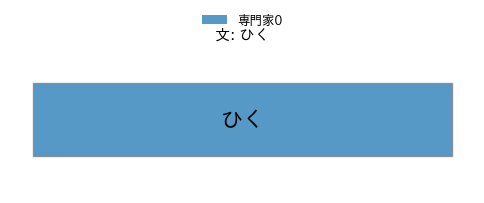

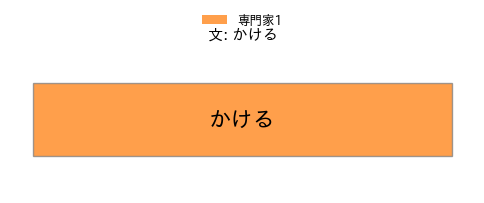

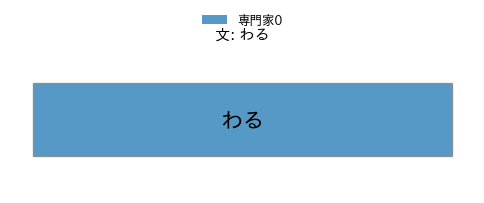

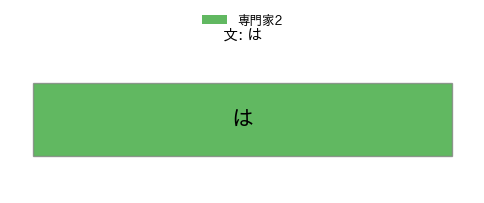

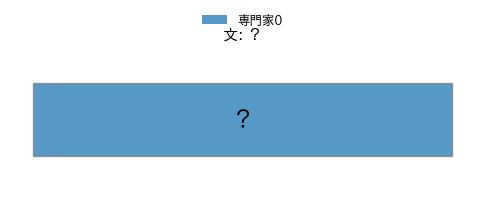

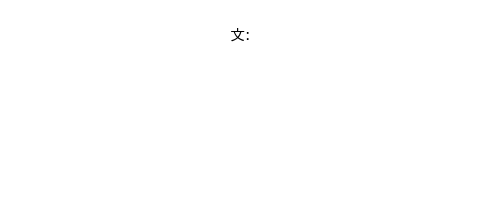

In [ ]:
#
for t in TOK2ID.keys():
    test.show_token_experts(model, args,  [TOK2ID[t]], ds )